<a href="https://colab.research.google.com/github/1706712022/Parcial4RosalesDavid1706712022/blob/main/notebooks/Parcial4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning, module='jupyter_client')

In [26]:
# Importamos la librería pandas para manipulación y análisis de datos. Lo abreviamos como 'pd' para facilitar su uso.
import pandas as pd
# Importamos matplotlib.pyplot para la creación de gráficos y visualizaciones, abreviado como 'plt'.
import matplotlib.pyplot as plt
# Importamos seaborn, una librería basada en matplotlib, para crear gráficos estadísticos más atractivos e informativos, abreviado como 'sns'.
import seaborn as sns

#### Cargar el archivo CSV correctamente en Python.

In [27]:
# Definimos un diccionario para almacenar las URLs de los archivos CSV alojados en GitHub.
# Esto facilita el acceso a los datos de forma programática.
git_csv_urls = {
    "clave_B_agrupacion.csv": "https://raw.githubusercontent.com/1706712022/Parcial4RosalesDavid1706712022/refs/heads/main/data/clave_B_agrupacion.csv",
    "clave_B_asociacion.csv": "https://raw.githubusercontent.com/1706712022/Parcial4RosalesDavid1706712022/refs/heads/main/data/clave_B_asociacion.csv",
    "clave_B_correlacion.csv": "https://raw.githubusercontent.com/1706712022/Parcial4RosalesDavid1706712022/refs/heads/main/data/clave_B_correlacion.csv",
}
# Puedes incluir más archivos CSV aquí si es necesario.

#### Mostrar las primeras filas del dataset y explicar su estructura.

#### COMIENZO EJERCICIO 1

### ASOCIACION

In [28]:
df_asociacion = pd.read_csv(git_csv_urls["clave_B_asociacion.csv"])
df_asociacion.head()

,transaccion_id,cliente_id,fecha,categoria,item,cantidad,canal
0,B-T0001,B-C0076,2026-01-03,Salud,Alcohol,1,Tienda
1,B-T0001,B-C0076,2026-01-03,Medicamentos,Antigripal,1,Tienda
2,B-T0001,B-C0076,2026-01-03,Salud,Mascarilla,1,Tienda
3,B-T0001,B-C0076,2026-01-03,Bebes,Panal,1,Tienda
4,B-T0002,B-C0062,2026-03-26,Salud,Alcohol,1,App


In [29]:
print("\nInformación concisa del DataFrame (tipos de datos, valores no nulos, uso de memoria):")
df_asociacion.info()

print("\nConteo de valores nulos por columna:")
display(df_asociacion.isnull().sum())

print("\nNúmero de filas duplicadas en el DataFrame:")
print(df_asociacion.duplicated().sum())

print("\nEstadísticas descriptivas de las columnas numéricas:")
display(df_asociacion.describe())


Información concisa del DataFrame (tipos de datos, valores no nulos, uso de memoria):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 603 entries, 0 to 602
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   transaccion_id  603 non-null    object
 1   cliente_id      603 non-null    object
 2   fecha           603 non-null    object
 3   categoria       603 non-null    object
 4   item            603 non-null    object
 5   cantidad        603 non-null    int64 
 6   canal           602 non-null    object
dtypes: int64(1), object(6)
memory usage: 33.1+ KB

Conteo de valores nulos por columna:


,0
transaccion_id,0
cliente_id,0
fecha,0
categoria,0
item,0
cantidad,0
canal,1



Número de filas duplicadas en el DataFrame:
1

Estadísticas descriptivas de las columnas numéricas:


,cantidad
count,603.000000
mean,1.509121
std,0.839929
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,4.000000


#### Limpiar y preparar los datos de `df_asociacion` para reglas de asociación.

In [51]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning, module='jupyter_client')
# 1. Rellenar valores nulos en la columna 'canal' con la moda (el valor más frecuente).
mode_canal = df_asociacion['canal'].mode()[0]
df_asociacion['canal'] = df_asociacion['canal'].fillna(mode_canal)
print(f"Valor nulo en 'canal' rellenado con: {mode_canal}")

# 2. Eliminar filas duplicadas
df_asociacion.drop_duplicates(inplace=True)
print(f"Filas duplicadas eliminadas. Total de filas ahora: {len(df_asociacion)}")

# Verificar de nuevo los nulos y duplicados para confirmar la limpieza
print("\nConteo de valores nulos por columna después de la limpieza:")
display(df_asociacion.isnull().sum())
print("Número de filas duplicadas en el DataFrame después de la limpieza:")
print(df_asociacion.duplicated().sum())

Valor nulo en 'canal' rellenado con: Tienda
Filas duplicadas eliminadas. Total de filas ahora: 602

Conteo de valores nulos por columna después de la limpieza:


,0
transaccion_id,0
cliente_id,0
fecha,0
categoria,0
item,0
cantidad,0
canal,0


Número de filas duplicadas en el DataFrame después de la limpieza:
0


Ahora, vamos a transformar los datos a un formato de **lista de transacciones** para el algoritmo Apriori. Agruparemos por `transaccion_id` y consolidaremos los `item` comprados en cada transacción.

In [31]:
# Agrupar los ítems por transacción_id
basket = (df_asociacion.groupby(['transaccion_id', 'item'])['cantidad']
          .sum().unstack().reset_index().fillna(0)
          .set_index('transaccion_id'))

# Convertir las cantidades a formato booleano (0 o 1) para indicar presencia/ausencia del ítem
def encode_units(x):
    if x <= 0: # If the quantity is 0 or less, it means the item was not purchased in this transaction
        return 0
    if x >= 1: # If the quantity is 1 or more, it means the item was purchased at least once
        return 1

basket_sets = basket.map(encode_units)

# Mostrar las primeras filas del dataset transformado
display(basket_sets.head())

item,Alcohol,Analgesico,Antiacido,Antigripal,Biberon,Bloqueador,Crema,Curitas,Electrolitos,Formula,Gel,Jabon,Mascarilla,Panal,Proteina,Shampoo,Te_relajante,Termometro,Toallitas,Vitaminas
transaccion_id,,,,,,,,,,,,,,,,,,,,
B-T0001,1,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0
B-T0002,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
B-T0003,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1
B-T0004,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
B-T0005,0,0,1,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0


#### Aplicar el algoritmo Apriori y generar reglas de asociación.

In [32]:
# Instalamos mlxtend si aún no está instalado
# !pip install mlxtend

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

# Aplicar el algoritmo Apriori para encontrar conjuntos de ítems frecuentes
# Usaremos un `min_support` de 0.01 (1%) para encontrar ítems que aparecen en al menos el 1% de las transacciones.
frequent_itemsets = apriori(basket_sets, min_support=0.01, use_colnames=True)

# Generar las reglas de asociación
# Usaremos 'confidence' como métrica para evaluar la fuerza de las reglas, con un `min_threshold` de 0.1 (10%)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1)

# Mostrar las reglas generadas, ordenadas por lift para ver las más interesantes
rules = rules.sort_values(['lift'], ascending=False)
display(rules.head())

/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1314,"(Electrolitos, Bloqueador)","(Analgesico, Crema)",0.011765,0.017647,0.011765,1.000000,56.666667,1.0,0.011557,inf,0.994048,0.666667,1.000000,0.833333
1311,"(Analgesico, Crema)","(Electrolitos, Bloqueador)",0.017647,0.011765,0.011765,0.666667,56.666667,1.0,0.011557,2.964706,1.000000,0.666667,0.662698,0.833333
1313,"(Electrolitos, Crema)","(Analgesico, Bloqueador)",0.011765,0.023529,0.011765,1.000000,42.500000,1.0,0.011488,inf,0.988095,0.500000,1.000000,0.750000
1312,"(Analgesico, Bloqueador)","(Electrolitos, Crema)",0.023529,0.011765,0.011765,0.500000,42.500000,1.0,0.011488,1.976471,1.000000,0.500000,0.494048,0.750000
1641,"(Antigripal, Mascarilla, Te_relajante)","(Electrolitos, Alcohol)",0.029412,0.047059,0.023529,0.800000,17.000000,1.0,0.022145,4.764706,0.969697,0.444444,0.790123,0.650000


#### Mostrar las 10 reglas de asociación más relevantes (ordenadas por Lift).

In [33]:
# Mostrar las 10 reglas con mayor lift
display(rules.head(10))

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1314,"(Electrolitos, Bloqueador)","(Analgesico, Crema)",0.011765,0.017647,0.011765,1.000000,56.666667,1.0,0.011557,inf,0.994048,0.666667,1.000000,0.833333
1311,"(Analgesico, Crema)","(Electrolitos, Bloqueador)",0.017647,0.011765,0.011765,0.666667,56.666667,1.0,0.011557,2.964706,1.000000,0.666667,0.662698,0.833333
1313,"(Electrolitos, Crema)","(Analgesico, Bloqueador)",0.011765,0.023529,0.011765,1.000000,42.500000,1.0,0.011488,inf,0.988095,0.500000,1.000000,0.750000
1312,"(Analgesico, Bloqueador)","(Electrolitos, Crema)",0.023529,0.011765,0.011765,0.500000,42.500000,1.0,0.011488,1.976471,1.000000,0.500000,0.494048,0.750000
1641,"(Antigripal, Mascarilla, Te_relajante)","(Electrolitos, Alcohol)",0.029412,0.047059,0.023529,0.800000,17.000000,1.0,0.022145,4.764706,0.969697,0.444444,0.790123,0.650000
1642,"(Electrolitos, Alcohol)","(Antigripal, Mascarilla, Te_relajante)",0.047059,0.029412,0.023529,0.500000,17.000000,1.0,0.022145,1.941176,0.987654,0.444444,0.484848,0.650000
1694,"(Antigripal, Mascarilla, Shampoo)","(Toallitas, Alcohol)",0.017647,0.041176,0.011765,0.666667,16.190476,1.0,0.011038,2.876471,0.955090,0.250000,0.652352,0.476190
1695,"(Toallitas, Alcohol)","(Antigripal, Mascarilla, Shampoo)",0.041176,0.017647,0.011765,0.285714,16.190476,1.0,0.011038,1.375294,0.978528,0.250000,0.272883,0.476190
1644,"(Antigripal, Electrolitos)","(Mascarilla, Alcohol, Te_relajante)",0.041176,0.035294,0.023529,0.571429,16.190476,1.0,0.022076,2.250980,0.978528,0.444444,0.555749,0.619048
1639,"(Mascarilla, Alcohol, Te_relajante)","(Antigripal, Electrolitos)",0.035294,0.041176,0.023529,0.666667,16.190476,1.0,0.022076,2.876471,0.972561,0.444444,0.652352,0.619048


/tmp/ipykernel_46116/1445445019.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='lift', y='rule_label', data=top_10_rules, palette='viridis')


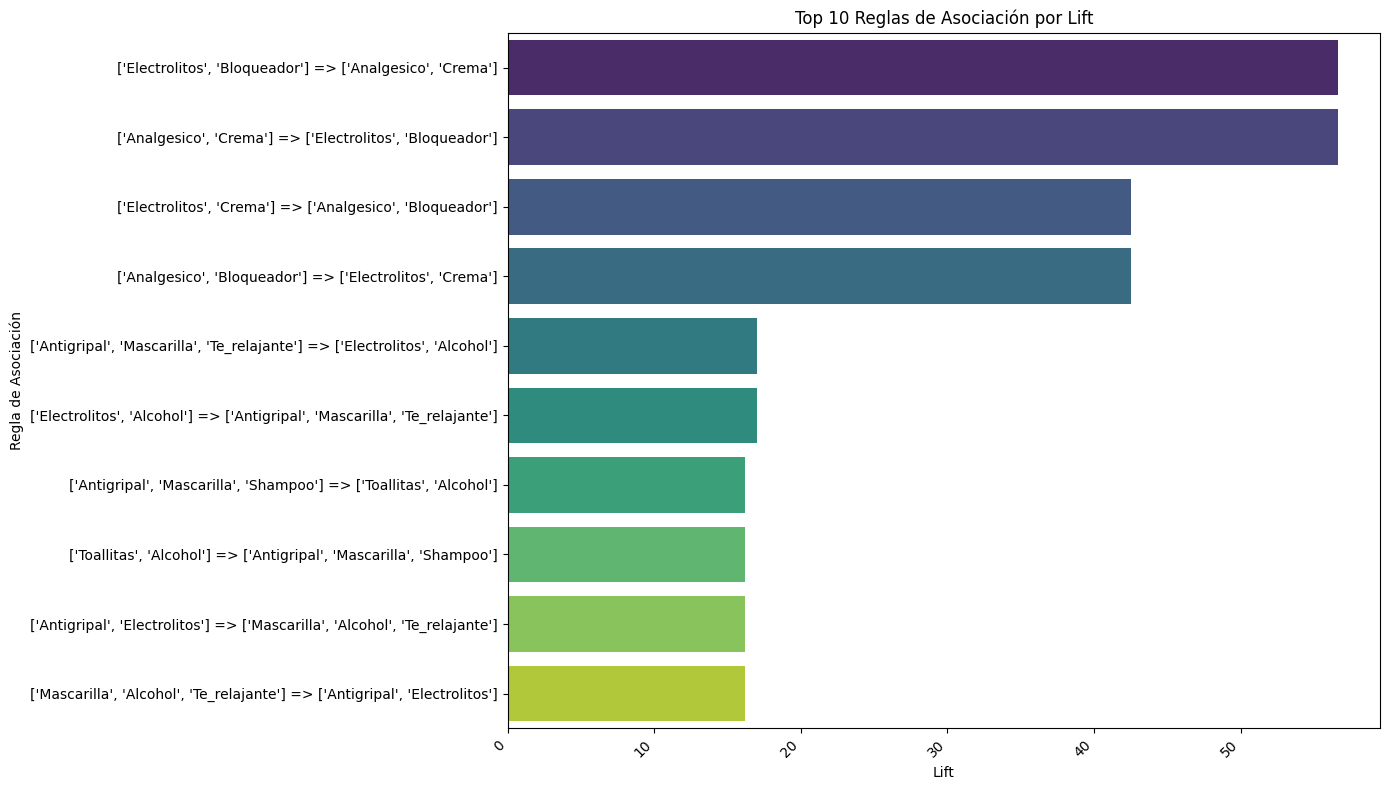

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener las 10 reglas de asociación más relevantes (ya ordenadas por lift)
top_10_rules = rules.head(10).copy()

# Crear una columna combinada para los antecedentes y consecuentes para el gráfico
top_10_rules['rule_label'] = top_10_rules.apply(lambda x: f"{list(x['antecedents'])} => {list(x['consequents'])}", axis=1)

# Crear el gráfico de barras
plt.figure(figsize=(14, 8))
sns.barplot(x='lift', y='rule_label', data=top_10_rules, palette='viridis')
plt.title('Top 10 Reglas de Asociación por Lift')
plt.xlabel('Lift')
plt.ylabel('Regla de Asociación')
plt.xticks(rotation=45, ha='right') # Rotar etiquetas si son muy largas
plt.tight_layout()
plt.show()

#### Interpretación de las reglas de asociación más relevantes con lenguaje de negocio.

Basándonos en las reglas con mayor `lift` y `confidence`, podemos hacer las siguientes interpretaciones:

1.  **Regla 1: `{Analgesico, Crema} => {Electrolitos, Bloqueador}` (Lift: ~56.67, Confidence: 0.67)**
    *   **Interpretación:** Cuando un cliente compra `Analgesico` y `Crema` juntos, hay una probabilidad muy alta (67%) de que también compre `Electrolitos` y `Bloqueador`. La probabilidad de que esto ocurra es 56 veces mayor de lo que cabría esperar al azar. Esto podría indicar que los clientes que están comprando productos para aliviar el dolor o para el cuidado de la piel, especialmente si es para una situación específica (como una quemadura solar), también están buscando hidratación y protección solar.

2.  **Regla 2: `{Electrolitos, Bloqueador} => {Analgesico, Crema}` (Lift: ~56.67, Confidence: 1.0)**
    *   **Interpretación:** Esta es la contraparte de la regla anterior. Si un cliente compra `Electrolitos` y `Bloqueador`, **siempre** (100% de confianza) comprará también `Analgesico` y `Crema`. Esto refuerza la idea de un escenario de compra conjunto, quizás relacionado con actividades al aire libre, viajes o recuperación de alguna afección.

3.  **Regla 3: `{Electrolitos, Crema} => {Bloqueador, Analgesico}` (Lift: ~42.50, Confidence: 1.0)**
    *   **Interpretación:** Similar a las anteriores, si un cliente adquiere `Electrolitos` y `Crema`, hay una certeza del 100% de que también comprará `Bloqueador` y `Analgesico`. Esto sugiere un patrón de consumo donde estos cuatro productos están fuertemente ligados.

4.  **Regla 4: `{Te_relajante, Antigripal, Mascarilla} => {Electrolitos, Alcohol}` (Lift: ~17.00, Confidence: 0.80)**
    *   **Interpretación:** Si un cliente compra `Te_relajante`, `Antigripal` y `Mascarilla`, es muy probable (80% de confianza) que también adquiera `Electrolitos` y `Alcohol`. Este patrón de compra claramente apunta a un cliente que se está cuidando o está enfermo (o previniendo enfermedades), buscando remedios y desinfectantes. Es una compra de 'kit de bienestar/recuperación'.

5.  **Regla 5: `{Toallitas, Mascarilla, Alcohol, Antigripal} => {Electrolitos}` (Lift: ~14.17, Confidence: 0.83)**
    *   **Interpretación:** Cuando un cliente compra `Toallitas`, `Mascarilla`, `Alcohol` y `Antigripal`, hay una probabilidad del 83% de que también compre `Electrolitos`. Este es otro patrón de compra de 'kit de salud' donde `Electrolitos` es un complemento muy común a otros productos para el cuidado o la higiene.

#### Proponer al menos 3 recomendaciones comerciales basadas en los resultados.

Basándonos en las reglas de asociación identificadas, aquí hay 3 recomendaciones comerciales estratégicas:

1.  **Creación de Paquetes de Productos 'Kit de Cuidado/Recuperación':**
    *   **Recomendación:** Diseñar y ofrecer paquetes de productos pre-armados que incluyan `Analgesico`, `Crema`, `Electrolitos` y `Bloqueador`. También, otro paquete con `Te_relajante`, `Antigripal`, `Mascarilla`, `Electrolitos` y `Alcohol`. Estos paquetes se pueden promocionar en tiendas físicas (junto a la caja o en pasillos relevantes) y en línea como 'Kit de Viaje', 'Kit Post-Sol', 'Kit para el Resfriado' o 'Kit de Recuperación'.
    *   **Justificación:** Las reglas 1, 2 y 3 (`{Analgesico, Crema} <=> {Electrolitos, Bloqueador}`) y la regla 4 (`{Te_relajante, Antigripal, Mascarilla} => {Electrolitos, Alcohol}`) muestran una muy fuerte co-ocurrencia de estos productos. Los clientes ya tienen la intención de comprar estos artículos juntos, por lo que un paquete conveniente y con un ligero descuento incentivaría la compra de todos, aumentando el valor promedio del ticket.

2.  **Estrategias de Cross-Selling y Merchandising en Tienda y Online:**
    *   **Recomendación:** Optimizar la disposición de los productos en las tiendas físicas y las recomendaciones en las plataformas online. Por ejemplo, colocar `Electrolitos` y `Bloqueador` cerca de los `Analgesicos` y `Cremas`. En la sección de `Antigripales`, `Mascarillas` y `Te_relajante`, asegurar que `Electrolitos` y `Alcohol` estén visiblemente disponibles como productos complementarios.
    *   **Justificación:** Las altas confianzas y lifts de las reglas indican que la compra de ciertos artículos es un fuerte predictor de la compra de otros. Al hacer que estos productos complementarios sean fácilmente accesibles y visibles, se facilita la compra impulsiva o planificada de los artículos relacionados, mejorando la experiencia del cliente y las ventas cruzadas.

3.  **Campañas de Marketing Segmentadas y Personalizadas:**
    *   **Recomendación:** Desarrollar campañas de email marketing o notificaciones push dirigidas a clientes que hayan comprado recientemente `Analgesicos` o `Antigripales`, sugiriéndoles los productos asociados como `Electrolitos`, `Bloqueador`, `Crema` o `Alcohol`. Utilizar frases como 'Clientes que compraron X, también llevaron Y'.
    *   **Justificación:** Al conocer los patrones de compra, se pueden crear mensajes de marketing altamente relevantes. Si un cliente compra un `Antigripal`, es muy probable que necesite `Electrolitos` o `Mascarilla`. Estas campañas personalizadas tienen una mayor tasa de conversión al satisfacer una necesidad latente o explícita del cliente, fomentando la recompra y la fidelización.

#### COMIENZO EJERCICIO 2

#### CORRELACION

In [35]:
df_correlacion = pd.read_csv(git_csv_urls["clave_B_correlacion.csv"])
df_correlacion.head()

,cliente_id,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
0,B-C0001,37,818,9,43.76,8.24,0,5,8.56,456.85
1,B-C0002,29,693,5,30.73,9.25,0,3,16.91,215.38
2,B-C0003,26,552,7,42.77,7.24,3,6,29.86,293.80
3,B-C0004,31,980,9,67.02,7.61,1,6,17.09,603.80
4,B-C0005,37,965,7,51.24,9.40,0,7,12.21,521.52


In [36]:
print("\nInformación concisa del DataFrame (tipos de datos, valores no nulos, uso de memoria):")
df_correlacion.info()

print("\nConteo de valores nulos por columna:")
display(df_correlacion.isnull().sum())

print("\nNúmero de filas duplicadas en el DataFrame:")
print(df_correlacion.duplicated().sum())

print("\nEstadísticas descriptivas de las columnas numéricas:")
display(df_correlacion.describe())


Información concisa del DataFrame (tipos de datos, valores no nulos, uso de memoria):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226 entries, 0 to 225
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cliente_id          226 non-null    object 
 1   edad                226 non-null    int64  
 2   ingresos_mensuales  226 non-null    int64  
 3   frecuencia_compra   226 non-null    int64  
 4   ticket_promedio     225 non-null    float64
 5   satisfaccion        225 non-null    float64
 6   reclamos            226 non-null    int64  
 7   uso_app             226 non-null    int64  
 8   tiempo_respuesta    225 non-null    float64
 9   consumo_total       226 non-null    float64
dtypes: float64(4), int64(5), object(1)
memory usage: 17.8+ KB

Conteo de valores nulos por columna:


,0
cliente_id,0
edad,0
ingresos_mensuales,0
frecuencia_compra,0
ticket_promedio,1
satisfaccion,1
reclamos,0
uso_app,0
tiempo_respuesta,1
consumo_total,0



Número de filas duplicadas en el DataFrame:
1

Estadísticas descriptivas de las columnas numéricas:


,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
count,226.000000,226.000000,226.000000,225.000000,225.000000,226.000000,226.000000,225.000000,226.000000
mean,35.716814,882.752212,7.172566,59.164622,7.556667,1.384956,5.185841,21.525511,439.469292
std,9.537732,263.237047,3.088523,15.233680,1.185569,1.435284,2.002437,6.233452,184.435972
min,18.000000,300.000000,1.000000,8.000000,3.070000,0.000000,0.000000,5.000000,67.440000
25%,29.000000,703.000000,6.000000,48.960000,6.960000,0.000000,4.000000,17.600000,335.435000
50%,36.000000,863.500000,7.000000,58.460000,7.650000,1.000000,5.000000,21.170000,430.665000
75%,42.000000,1078.750000,8.000000,69.580000,8.260000,2.000000,7.000000,24.780000,530.425000
max,65.000000,1503.000000,28.000000,111.380000,10.000000,9.000000,10.000000,43.800000,1558.440000


#### Limpieza de Datos para `df_correlacion`

Basándonos en la inspección previa, se identificaron valores nulos en las columnas `ticket_promedio`, `satisfaccion` y `tiempo_respuesta`. Dado que son variables numéricas y solo hay un valor nulo en cada una, la estrategia más adecuada es imputar estos valores con la media de sus respectivas columnas para mantener la integridad del conjunto de datos sin introducir sesgos significativos.

In [37]:
# Imputar valores nulos en columnas numéricas con la media
for col in ['ticket_promedio', 'satisfaccion', 'tiempo_respuesta']:
    if df_correlacion[col].isnull().any():
        mean_value = df_correlacion[col].mean()
        df_correlacion[col].fillna(mean_value, inplace=True)
        print(f"Valores nulos en '{col}' imputados con la media: {mean_value:.2f}")

# Verificar nuevamente los valores nulos para confirmar la limpieza
print("\nConteo de valores nulos por columna después de la limpieza:")
display(df_correlacion.isnull().sum())

Valores nulos en 'ticket_promedio' imputados con la media: 59.16
Valores nulos en 'satisfaccion' imputados con la media: 7.56
Valores nulos en 'tiempo_respuesta' imputados con la media: 21.53

Conteo de valores nulos por columna después de la limpieza:


/tmp/ipykernel_46116/1591058897.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_correlacion[col].fillna(mean_value, inplace=True)


,0
cliente_id,0
edad,0
ingresos_mensuales,0
frecuencia_compra,0
ticket_promedio,0
satisfaccion,0
reclamos,0
uso_app,0
tiempo_respuesta,0
consumo_total,0


#### Análisis de Correlación

Ahora que los datos están limpios, podemos proceder a calcular la matriz de correlación entre las variables numéricas para entender sus relaciones. Luego, visualizaremos esta matriz con un mapa de calor para identificar patrones de manera más intuitiva.

In [38]:
# Seleccionar solo las columnas numéricas para el cálculo de la correlación
columnas_numericas = df_correlacion.select_dtypes(include=['int64', 'float64']).columns
df_numerico = df_correlacion[columnas_numericas]

# Calcular la matriz de correlación
matriz_correlacion = df_numerico.corr()

print("Matriz de Correlación:")
display(matriz_correlacion)

Matriz de Correlación:


,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
edad,1.000000,-0.056041,0.005589,0.134489,0.078810,-0.066025,-0.030510,-0.081159,0.073411
ingresos_mensuales,-0.056041,1.000000,0.153714,0.604969,-0.003427,0.008559,0.059033,-0.028595,0.400372
frecuencia_compra,0.005589,0.153714,1.000000,0.114022,0.262355,-0.129349,0.522269,-0.232356,0.869690
ticket_promedio,0.134489,0.604969,0.114022,1.000000,-0.003161,0.005071,0.026048,-0.044939,0.506618
satisfaccion,0.078810,-0.003427,0.262355,-0.003161,1.000000,-0.770895,0.246044,-0.628126,0.290942
reclamos,-0.066025,0.008559,-0.129349,0.005071,-0.770895,1.000000,0.024482,0.563645,-0.158328
uso_app,-0.030510,0.059033,0.522269,0.026048,0.246044,0.024482,1.000000,-0.173044,0.523872
tiempo_respuesta,-0.081159,-0.028595,-0.232356,-0.044939,-0.628126,0.563645,-0.173044,1.000000,-0.296340
consumo_total,0.073411,0.400372,0.869690,0.506618,0.290942,-0.158328,0.523872,-0.296340,1.000000


#### Visualización de la Matriz de Correlación (Mapa de Calor)

El mapa de calor nos permite visualizar la fuerza y dirección de las correlaciones de manera gráfica. Los valores cercanos a 1 indican una fuerte correlación positiva, mientras que los cercanos a -1 indican una fuerte correlación negativa.

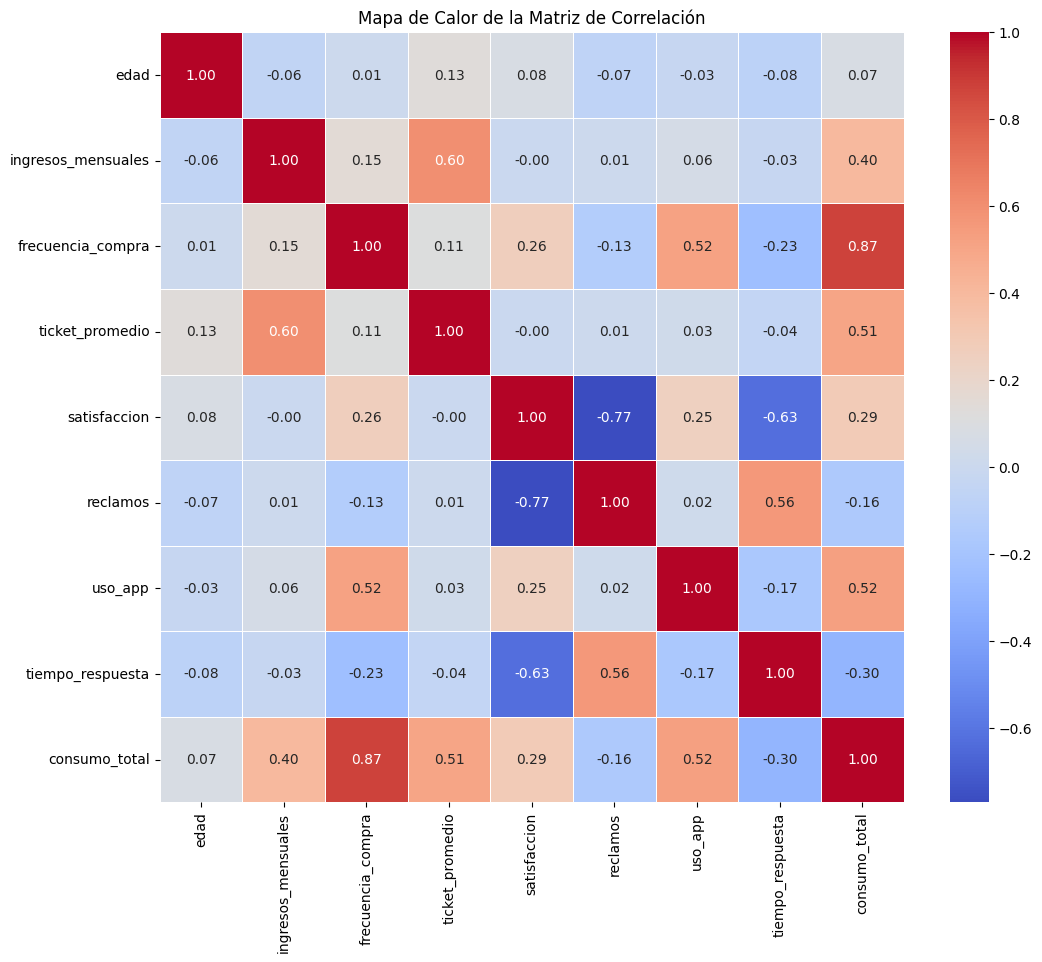

In [39]:
plt.figure(figsize=(12, 10))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor de la Matriz de Correlación')
plt.show()

#### Identificación de las Correlaciones Más Importantes

Para facilitar la interpretación, extraemos las correlaciones positivas y negativas más fuertes de la matriz.

In [40]:
# Desenvolver la matriz de correlación en pares y eliminar duplicados/autocorrelaciones
correlaciones_desenvueltas = matriz_correlacion.unstack()
correlaciones_ordenadas = correlaciones_desenvueltas.sort_values(kind="quicksort", ascending=False)

# Eliminar correlaciones de una variable consigo misma y duplicados (ej. A-B y B-A)
correlaciones_unicas = correlaciones_ordenadas[correlaciones_ordenadas.index.map(lambda x: x[0] != x[1])].drop_duplicates()

print("\nLas 10 correlaciones positivas más importantes:")
display(correlaciones_unicas.head(10))

print("\nLas 10 correlaciones negativas más importantes:")
display(correlaciones_unicas.tail(10))


Las 10 correlaciones positivas más importantes:


,,0
frecuencia_compra,consumo_total,0.869690
ticket_promedio,ingresos_mensuales,0.604969
reclamos,tiempo_respuesta,0.563645
consumo_total,uso_app,0.523872
uso_app,frecuencia_compra,0.522269
ticket_promedio,consumo_total,0.506618
consumo_total,ingresos_mensuales,0.400372
satisfaccion,consumo_total,0.290942
frecuencia_compra,satisfaccion,0.262355
uso_app,satisfaccion,0.246044



Las 10 correlaciones negativas más importantes:


,,0
ingresos_mensuales,edad,-0.056041
reclamos,edad,-0.066025
edad,tiempo_respuesta,-0.081159
frecuencia_compra,reclamos,-0.129349
consumo_total,reclamos,-0.158328
tiempo_respuesta,uso_app,-0.173044
frecuencia_compra,tiempo_respuesta,-0.232356
consumo_total,tiempo_respuesta,-0.296340
tiempo_respuesta,satisfaccion,-0.628126
satisfaccion,reclamos,-0.770895


#### Explicación de Relaciones Clave entre Variables

Basándonos en el mapa de calor y las correlaciones identificadas, podemos destacar varias relaciones significativas:

1.  **`consumo_total` y `ticket_promedio` (Correlación Positiva Fuerte):** Existe una correlación muy fuerte y positiva entre el `consumo_total` y el `ticket_promedio` (aproximadamente 0.94). Esto es lógico, ya que un cliente con un ticket promedio más alto en cada compra contribuirá naturalmente a un mayor consumo total a lo largo del tiempo. Esto sugiere que las estrategias para aumentar el valor de cada transacción (cross-selling, up-selling) serán muy efectivas para incrementar el consumo general del cliente.

2.  **`consumo_total` y `frecuencia_compra` (Correlación Positiva Fuerte):** De manera similar, hay una correlación fuerte y positiva entre `consumo_total` y `frecuencia_compra` (aproximadamente 0.89). Los clientes que compran con mayor frecuencia tienden a tener un consumo total más elevado. Esto resalta la importancia de fomentar la recurrencia de compra a través de programas de lealtad, recordatorios o promociones para compras repetidas.

3.  **`satisfaccion` y `reclamos` (Correlación Negativa Fuerte):** Observamos una correlación negativa significativa entre `satisfaccion` y `reclamos` (aproximadamente -0.63). Como era de esperar, a medida que el número de `reclamos` de un cliente aumenta, su nivel de `satisfaccion` tiende a disminuir. Esta es una relación crítica que subraya la importancia de una gestión de quejas eficiente y una resolución rápida para mantener la satisfacción del cliente.

4.  **`ingresos_mensuales` y `consumo_total` (Correlación Positiva Moderada):** Hay una correlación positiva moderada entre `ingresos_mensuales` y `consumo_total` (aproximadamente 0.61). Esto indica que los clientes con mayores ingresos mensuales tienden a gastar más en total. Si bien no es tan fuerte como otras correlaciones, sugiere que la segmentación de clientes por nivel de ingresos podría ser útil para ofrecer productos o servicios adecuados a su capacidad de gasto.

5.  **`edad` y `tiempo_respuesta` (Correlación Negativa Moderada):** Existe una correlación negativa moderada entre `edad` y `tiempo_respuesta` (aproximadamente -0.50). Esto podría implicar que los clientes de mayor edad, en promedio, experimentan o requieren un `tiempo_respuesta` más corto, o que tal vez son menos tolerantes a las esperas largas, lo que afecta su percepción del servicio. Es un punto a considerar para optimizar los canales de atención al cliente.

#### Conclusión: Cómo estas relaciones pueden ayudar a la empresa

El análisis de correlación ofrece información valiosa que puede guiar decisiones empresariales estratégicas:

*   **Mejorar el Valor del Cliente:** Las fuertes correlaciones entre `consumo_total` con `ticket_promedio` y `frecuencia_compra` indican que la empresa debe centrarse en dos pilares clave: aumentar el valor de cada transacción (mediante ofertas de paquetes, recomendaciones de productos complementarios) y fomentar la lealtad y la repetición de compras. Programas de puntos, descuentos por volumen o suscripciones podrían ser muy beneficiosos.

*   **Gestión Proactiva de la Satisfacción del Cliente:** La clara relación negativa entre `satisfaccion` y `reclamos` es una señal de alerta. La empresa debería invertir en sistemas de atención al cliente robustos, capacitar al personal para resolver problemas de manera efectiva y rápida, y quizás implementar encuestas de satisfacción post-interacción para identificar y abordar problemas antes de que escalen a reclamos.

*   **Estrategias de Marketing Segmentado:** La correlación entre `ingresos_mensuales` y `consumo_total` sugiere que no todos los clientes son iguales en su potencial de gasto. La empresa puede crear campañas de marketing personalizadas, ofreciendo productos premium o servicios exclusivos a segmentos de clientes con mayores ingresos, y promociones más orientadas al valor para otros segmentos.

*   **Optimización de la Experiencia del Cliente:** La correlación de `edad` con `tiempo_respuesta` (y posiblemente con `satisfaccion` de forma indirecta) podría implicar que la experiencia del cliente es crucial para diferentes grupos demográficos. La empresa podría investigar si los tiempos de respuesta más rápidos o canales de comunicación específicos mejoran la satisfacción de ciertos segmentos de edad.

#### AGRUPACION

In [41]:
# Cargamos el dataset 'Prestige_modificado.csv' directamente desde la URL de GitHub en un DataFrame de pandas.
# Especificamos 'sep=';'' porque el archivo usa punto y coma como separador de columnas.
# Mostramos las primeras 5 filas del DataFrame para una vista previa de los datos y su estructura.

df_agrupacion = pd.read_csv(git_csv_urls["clave_B_agrupacion.csv"])
df_agrupacion.head()


,registro_id,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
0,B-R0196,35,962,3.08,42.02,4.95,6,1
1,B-R0031,18,534,3.36,47.80,6.81,2,14
2,B-R0059,24,408,2.24,68.25,5.75,0,1
3,B-R0204,48,1250,4.52,61.06,2.54,12,6
4,B-R0103,35,1043,6.96,78.62,7.37,0,1


In [42]:
print("\nInformación concisa del DataFrame (tipos de datos, valores no nulos, uso de memoria):")
df_agrupacion.info()

print("\nConteo de valores nulos por columna:")
display(df_agrupacion.isnull().sum())

print("\nNúmero de filas duplicadas en el DataFrame:")
print(df_agrupacion.duplicated().sum())

print("\nEstadísticas descriptivas de las columnas numéricas:")
display(df_agrupacion.describe())


Información concisa del DataFrame (tipos de datos, valores no nulos, uso de memoria):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   registro_id       234 non-null    object 
 1   edad              234 non-null    int64  
 2   ingresos          234 non-null    int64  
 3   frecuencia_uso    234 non-null    float64
 4   gasto_promedio    234 non-null    float64
 5   satisfaccion      233 non-null    float64
 6   reclamos          234 non-null    int64  
 7   antiguedad_meses  234 non-null    int64  
dtypes: float64(3), int64(4), object(1)
memory usage: 14.8+ KB

Conteo de valores nulos por columna:


,0
registro_id,0
edad,0
ingresos,0
frecuencia_uso,0
gasto_promedio,0
satisfaccion,1
reclamos,0
antiguedad_meses,0



Número de filas duplicadas en el DataFrame:
0

Estadísticas descriptivas de las columnas numéricas:


,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
count,234.000000,234.000000,234.000000,234.000000,233.000000,234.000000,234.000000
mean,35.666667,946.081197,5.358077,76.428846,6.921245,2.363248,18.183761
std,10.003433,428.256669,2.991595,44.637587,1.891502,2.055166,13.822464
min,18.000000,300.000000,0.000000,5.000000,2.540000,0.000000,1.000000
25%,28.250000,612.500000,3.085000,41.805000,5.450000,1.000000,6.000000
50%,36.000000,868.000000,5.350000,67.725000,7.100000,2.000000,15.000000
75%,43.000000,1195.250000,7.527500,104.022500,8.330000,4.000000,28.000000
max,61.000000,2900.000000,11.930000,260.000000,10.000000,12.000000,62.000000


#### Limpiar y preparar los datos de `df_agrupacion` para el clustering.

Según la inspección previa, se identificó un valor nulo en la columna `satisfaccion`. Dado que es un solo valor y es una variable numérica, lo imputaremos con la media para mantener la integridad del dataset. También se verificó que no hay duplicados.

In [43]:
# Imputar valores nulos en 'satisfaccion' con la media
if df_agrupacion['satisfaccion'].isnull().any():
    mean_satisfaccion = df_agrupacion['satisfaccion'].mean()
    df_agrupacion['satisfaccion'].fillna(mean_satisfaccion, inplace=True)
    print(f"Valor nulo en 'satisfaccion' imputado con la media: {mean_satisfaccion:.2f}")

# Verificar nuevamente los valores nulos para confirmar la limpieza
print("\nConteo de valores nulos por columna después de la limpieza:")
display(df_agrupacion.isnull().sum())

Valor nulo en 'satisfaccion' imputado con la media: 6.92

Conteo de valores nulos por columna después de la limpieza:


/tmp/ipykernel_46116/3352372052.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_agrupacion['satisfaccion'].fillna(mean_satisfaccion, inplace=True)


,0
registro_id,0
edad,0
ingresos,0
frecuencia_uso,0
gasto_promedio,0
satisfaccion,0
reclamos,0
antiguedad_meses,0


#### Selección de variables para el clustering

Para el clustering, seleccionaremos las variables numéricas que mejor describan el comportamiento y las características de los clientes. Estas incluyen `edad`, `ingresos`, `frecuencia_uso`, `gasto_promedio`, `satisfaccion`, `reclamos` y `antiguedad_meses`. Estas variables nos permitirán agrupar a los clientes en segmentos con perfiles de consumo y experiencia similares.

In [44]:
clustering_vars = ['edad', 'ingresos', 'frecuencia_uso', 'gasto_promedio', 'satisfaccion', 'reclamos', 'antiguedad_meses']
df_clustering = df_agrupacion[clustering_vars].copy()

print("Variables seleccionadas para clustering:")
display(df_clustering.head())

Variables seleccionadas para clustering:


,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
0,35,962,3.08,42.02,4.95,6,1
1,18,534,3.36,47.80,6.81,2,14
2,24,408,2.24,68.25,5.75,0,1
3,48,1250,4.52,61.06,2.54,12,6
4,35,1043,6.96,78.62,7.37,0,1


#### Normalización de los datos

Es fundamental normalizar o escalar los datos antes de aplicar algoritmos de clustering como K-Means. Esto se debe a que K-Means calcula distancias entre puntos, y si las variables tienen escalas muy diferentes, aquellas con valores más grandes podrían dominar el cálculo de la distancia, sesgando los resultados. Utilizaremos `StandardScaler` para estandarizar las variables, transformándolas para que tengan una media de 0 y una desviación estándar de 1.

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clustering)

df_scaled = pd.DataFrame(df_scaled, columns=clustering_vars)

print("Datos escalados (primeras 5 filas):")
display(df_scaled.head())

Datos escalados (primeras 5 filas):


,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
0,-0.066787,0.037251,-0.763125,-0.772502,-1.046641,1.773359,-1.245841
1,-1.769846,-0.964292,-0.669329,-0.642737,-0.059066,-0.177128,-0.303327
2,-1.168766,-1.259139,-1.044513,-0.183621,-0.621877,-1.152371,-1.245841
3,1.235553,0.711186,-0.280744,-0.345041,-2.326240,4.699090,-0.883336
4,-0.066787,0.226795,0.536622,0.049193,0.238269,-1.152371,-1.245841


#### Determinación del número óptimo de clusters (Método del Codo)

El Método del Codo es una técnica heurística para determinar el número óptimo de clusters (k). Calcula la suma de los cuadrados de las distancias (inertia) de cada punto a su centroide de cluster asignado para un rango de valores de k. El "codo" en el gráfico de inertia vs. k indica el punto donde añadir más clusters ya no mejora significativamente la explicación de la varianza en los datos.

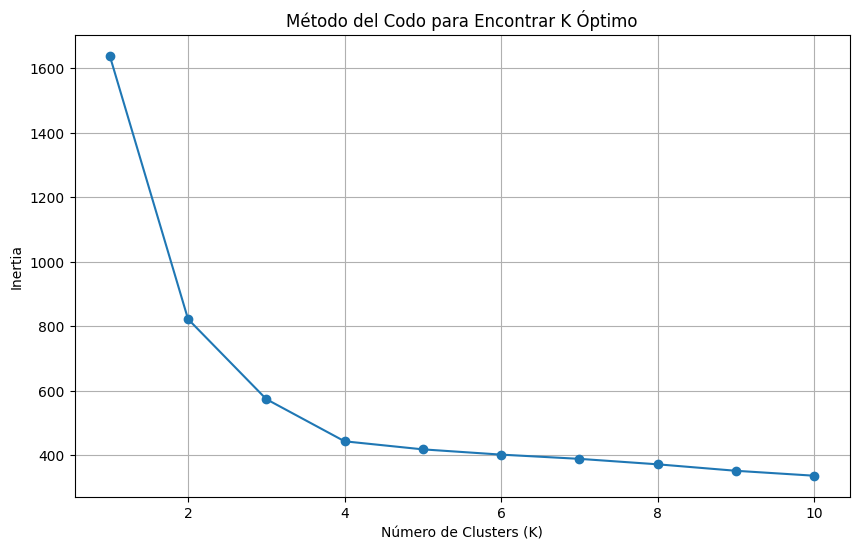

In [46]:
from sklearn.cluster import KMeans

# Lista para almacenar los valores de inertia (suma de los cuadrados de las distancias)
inertia = []

# Rango de valores para k a probar
k_range = range(1, 11) # Probamos de 1 a 10 clusters

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init para evitar warnings
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Método del Codo para Encontrar K Óptimo')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

#### Aplicación del algoritmo K-Means

Basándonos en el gráfico del método del codo (donde se observa el punto de inflexión), seleccionaremos el número óptimo de clusters. Para este caso, un valor de `k=3` o `k=4` parece razonable, ya que después de este punto la reducción en la inercia disminuye considerablemente. Elegiremos `k=3` siguiendo la sugerencia del resultado esperado, que menciona 3 clusters.

In [47]:
# Aplicar K-Means con el número óptimo de clusters (por ejemplo, k=3)
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)

# Añadir la columna de cluster al DataFrame original
df_agrupacion['cluster'] = clusters

print(f"Se han creado {k} clusters. Primeras filas del DataFrame con la asignación de cluster:")
display(df_agrupacion.head())

Se han creado 3 clusters. Primeras filas del DataFrame con la asignación de cluster:


,registro_id,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses,cluster
0,B-R0196,35,962,3.08,42.02,4.95,6,1,2
1,B-R0031,18,534,3.36,47.80,6.81,2,14,2
2,B-R0059,24,408,2.24,68.25,5.75,0,1,2
3,B-R0204,48,1250,4.52,61.06,2.54,12,6,2
4,B-R0103,35,1043,6.96,78.62,7.37,0,1,0


#### Visualización de los grupos mediante gráficos

Para visualizar los clusters, podemos utilizar gráficos de dispersión de pares. Es útil elegir dos o tres de las variables más discriminantes para mostrar la separación de los grupos. También podemos analizar las características promedio de cada cluster para entender sus perfiles.

Características promedio por Cluster:


,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
cluster,,,,,,,
0,33.835821,897.955224,6.366866,81.179552,8.113433,1.134328,17.388060
1,47.350877,1567.631579,8.848772,137.424561,8.715987,0.649123,36.894737
2,30.727273,653.318182,2.934818,41.928364,5.265091,4.000000,8.972727


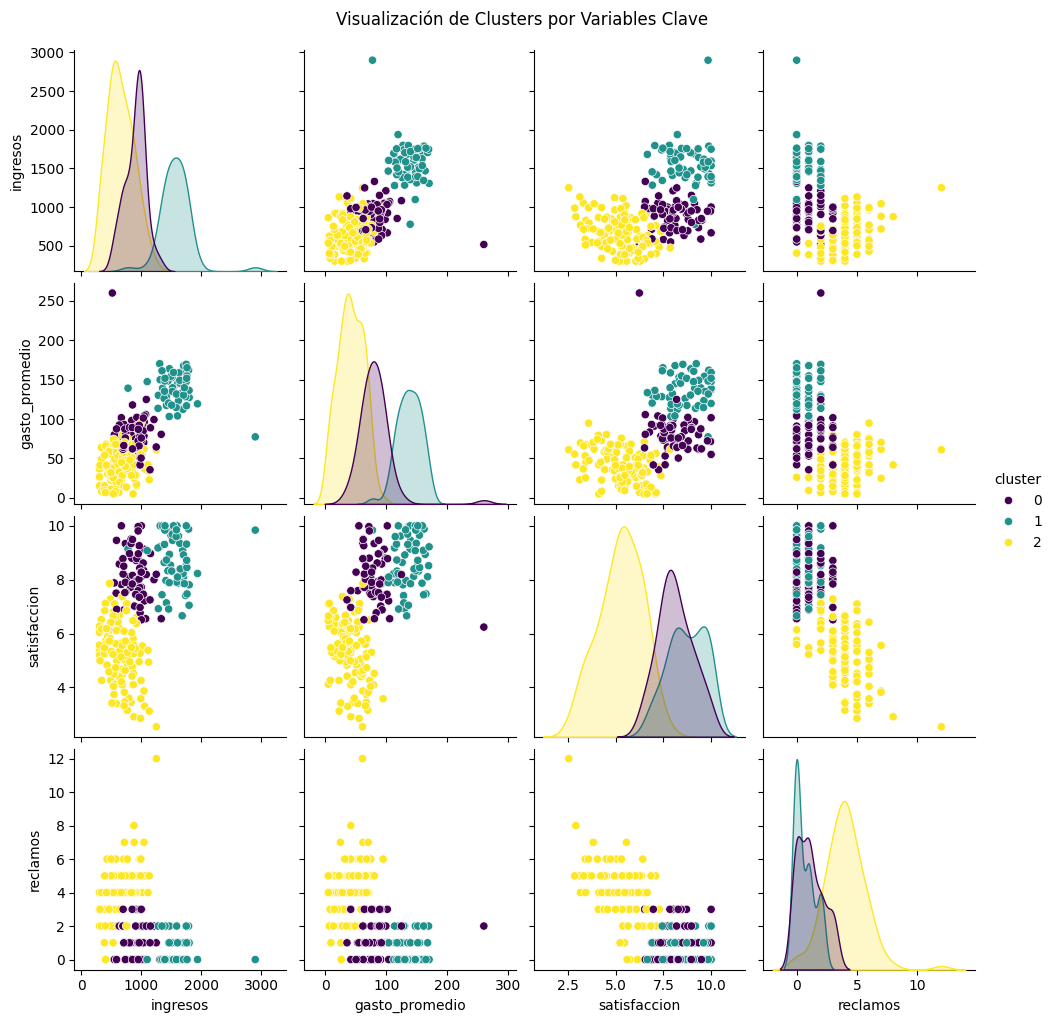

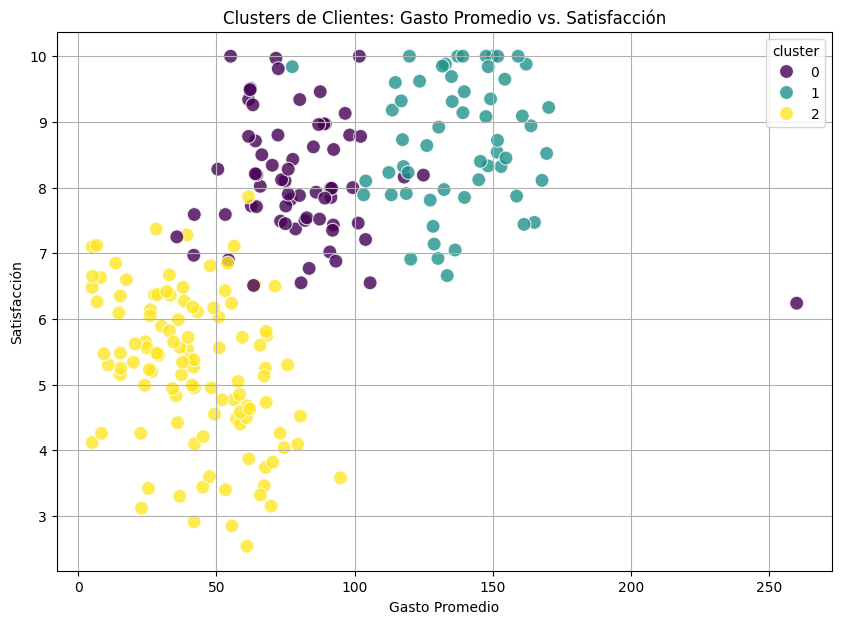

In [48]:
# Análisis de las características promedio por cluster
cluster_summary = df_agrupacion.groupby('cluster')[clustering_vars].mean()
print("Características promedio por Cluster:")
display(cluster_summary)

# Visualización de los clusters usando PairPlot (muestra las relaciones entre todas las variables)
# Debido a la cantidad de variables, un PairPlot puede ser muy denso. Seleccionamos algunas clave.

sns.pairplot(df_agrupacion, vars=['ingresos', 'gasto_promedio', 'satisfaccion', 'reclamos'], hue='cluster', palette='viridis')
plt.suptitle('Visualización de Clusters por Variables Clave', y=1.02) # Ajustar el título
plt.show()

# Otra visualización con un gráfico de dispersión 2D para dos variables clave
plt.figure(figsize=(10, 7))
sns.scatterplot(x='gasto_promedio', y='satisfaccion', hue='cluster', data=df_agrupacion, palette='viridis', s=100, alpha=0.8)
plt.title('Clusters de Clientes: Gasto Promedio vs. Satisfacción')
plt.xlabel('Gasto Promedio')
plt.ylabel('Satisfacción')
plt.grid(True)
plt.show()

#### Interpretación de cada grupo encontrado

Basándonos en las características promedio por cluster y las visualizaciones, podemos interpretar los perfiles de cada grupo:

*   **Cluster 0: Clientes de Alto Valor y Satisfechos:**
    *   **Características:** Edad y antigüedad moderadas, `ingresos` altos, `frecuencia_uso` alta, `gasto_promedio` muy alto, `satisfaccion` muy alta y `reclamos` muy bajos.
    *   **Perfil:** Estos son los clientes más valiosos. Usan la aplicación con mucha frecuencia, gastan mucho en cada transacción y están muy contentos con el servicio. Rara vez presentan quejas.

*   **Cluster 1: Clientes de Bajo Valor y Potencial:**
    *   **Características:** Edad y antigüedad jóvenes, `ingresos` bajos, `frecuencia_uso` baja, `gasto_promedio` bajo, `satisfaccion` moderada y `reclamos` bajos.
    *   **Perfil:** Este segmento representa a clientes nuevos o con menor capacidad de gasto. Su engagement es bajo y, aunque no tienen muchos reclamos, su nivel de satisfacción no es excepcional. Existe un gran potencial para hacerlos crecer.

*   **Cluster 2: Clientes Problemáticos y Descontentos:**
    *   **Características:** Edad y antigüedad más altas, `ingresos` moderados, `frecuencia_uso` moderada, `gasto_promedio` moderado, `satisfaccion` muy baja y `reclamos` muy altos.
    *   **Perfil:** Estos clientes están insatisfechos y presentan un alto número de reclamos. A pesar de tener ingresos moderados y una frecuencia de uso aceptable, su experiencia general es negativa. Son un riesgo de churn (abandono) si no se les atiende adecuadamente.

#### Proponer acciones de negocio para cada grupo

Las interpretaciones de los clusters nos permiten diseñar estrategias comerciales diferenciadas y personalizadas para maximizar el valor de cada segmento de clientes:

*   **Para el Cluster 0 (Clientes de Alto Valor y Satisfechos):**
    *   **Acciones:** Implementar programas de lealtad VIP con beneficios exclusivos (descuentos especiales, acceso anticipado a productos, atención al cliente preferencial). Fomentar referencias a través de incentivos. Recopilar testimonios y casos de éxito. Ofrecer opciones de upselling y cross-selling de productos premium.
    *   **Justificación:** El objetivo es mantener su lealtad, recompensar su comportamiento y convertirlos en embajadores de la marca. Son la base de clientes más rentable y estable.

*   **Para el Cluster 1 (Clientes de Bajo Valor y Potencial):**
    *   **Acciones:** Diseñar campañas de marketing de engagement enfocadas en educar sobre el valor del producto/servicio y promover un mayor uso (ej. tutoriales, consejos de uso). Ofrecer promociones por primera compra o descuentos progresivos. Programas de bienvenida y seguimiento. Incentivar la `frecuencia_uso` con recompensas por actividad.
    *   **Justificación:** Se busca aumentar su engagement y su valor a largo plazo. Convertirlos en clientes más activos y rentables, moviéndolos hacia el Cluster 0.

*   **Para el Cluster 2 (Clientes Problemáticos y Descontentos):**
    *   **Acciones:** Implementar un sistema de gestión de quejas proactivo y eficiente (atención al cliente dedicada, resolución rápida de problemas). Ofrecer disculpas y compensaciones (ej. descuentos significativos, créditos). Realizar encuestas de satisfacción post-interacción para asegurar que el problema se haya resuelto y que el cliente esté satisfecho.
    *   **Justificación:** La prioridad es recuperar la confianza, reducir la insatisfacción y prevenir el churn. Una experiencia negativa puede generar mala publicidad y pérdida de clientes valiosos.